# Lab 08: Vision Transformers and VLMs, Talking to Your Images

**ITAI 1378  |  Module 08 Companion Lab  |  2026**

**Author:** Patricia McManus     **Collaborator:** Claude (Anthropic)

**Course:** AI and Robotics Program, Digital and Information Technology Center of Excellence, Houston City College

---

In Module 08 you learned how Vision Transformers chop an image into patches and treat them like words, and how Vision Language Models (VLMs) connect a model's eyes to a language model so it can describe, answer, and reason about images. The frontier VLMs you studied (GPT-5.5, Claude Opus 4.7, the Gemini 3 family) cost money per image. Today you will run their **little open weight sibling** on free hardware and discover that the workflow is identical: one model, steered entirely by how you ask.

**By the end of this lab you will be able to:**

1. Visualize how a Vision Transformer "reads" an image as patches
2. Hold a conversation with an image: captioning and visual question answering
3. Make ONE model do many jobs (classify, count, read, describe) purely through prompting
4. Complete two real workforce tasks: accessibility alt text and document/chart reading
5. Audit a VLM's reliability and catch it hallucinating
6. Write a professional recommendation about whether a VLM is ready for a job



## How This Lab Works

* Cells marked **RUN AS IS** are complete. Run them and read the comments.
* Cells marked **YOUR CODE HERE** have a TODO for you to complete. Tips are in the comments.
* Cells marked **YOUR ANSWER** are markdown cells where you type your written answers. Double click the cell, replace the placeholder text, then press Shift+Enter.
* **YOUR TURN** sections are graded checkpoints. **Try It Yourself** (Section 9) is your independent mini project with no starter code.

### Your GPU Budget (read this!)

This lab is even lighter than Lab 07:

* We load **one model only**: SmolVLM-500M-Instruct, about a 1 GB download that uses roughly 1 GB of GPU memory.
* Each question you ask takes a few seconds. The whole lab needs a few dozen questions.
* The CPU fallback is genuinely usable this time. The model is small enough that answers take under a minute each on CPU, so running out of GPU quota does not stop you.
* Plan to finish in one sitting so the downloaded model stays cached.

**Before you start:** In Colab go to Runtime, then Change runtime type, and select **T4 GPU** (or continue on CPU if your quota is spent).

## Grading Rubric (100 points, bonus available)

**Implementation, 60 points (six items, 10 points each)**

| Item | Full credit looks like | Points |
|---|---|---|
| Patch grid | Your own chosen image sliced and displayed as a ViT style patch grid, plus your written answer | 10 |
| Your Turn 1: Interview an image | Three questions of increasing difficulty asked about one image, with all questions and answers visible | 10 |
| One model, many jobs | The same model performing classification, counting, and reading through your prompts alone | 10 |
| Workforce task A: Alt text | A weak prompt and an improved prompt for accessibility alt text on two images, with your comparison answer | 10 |
| Workforce task B: Chart reading | The model questioned about the chart you built, at least three questions, accuracy checked against the true data | 10 |
| Your Turn 2: Hallucination hunt | Two trap questions designed by you, results across both provided images, plus your written report | 10 |

**Analysis, 40 points**

| Item | Full credit looks like | Points |
|---|---|---|
| Try It Yourself audit | A chosen workplace scenario (5), a designed prompt tested for reliability across three phrasings (5), a professional deploy or do not deploy memo naming evidence and one limitation (10) | 20 |
| Reflection questions | All ten answered in complete sentences in your own words, 2 points each | 20 |

**Bonus, up to 20 points:** see Section 11.

**Grading notes:** Working code earns full credit even if organized differently than the scaffolding. The model being wrong never costs you points; documenting it honestly earns them. What is graded is your process and your judgment. There is no deduction for late submission.

**Academic integrity:** Written answers must be your own words. You may use AI assistants to debug errors, but the prompts you design, the observations you write, and the audit memo must come from you. Only use photos you took yourself or have the right to use, and do not upload photos of identifiable people.

**Submission:** This notebook is the only deliverable. Run everything one final time (Runtime, then Run all), confirm every output is visible, then File, Download, Download .ipynb **with all outputs visible**. Name it **L08_LastName_FirstName_ITAI1378.ipynb** and submit to Canvas.

## Section 1: Setup

**RUN AS IS.** We install the Hugging Face libraries and detect your hardware. Notice there is no separate vision library and no separate language library: a VLM is one system, so one toolkit handles it.

In [26]:
# RUN AS IS
!pip install -q "transformers<5" accelerate

import torch

if torch.cuda.is_available():
    DEVICE = "cuda"
    DTYPE = torch.float16
    print("GPU ready:", torch.cuda.get_device_name(0))
else:
    DEVICE = "cpu"
    DTYPE = torch.float32
    print("CPU fallback active. This model is small enough that CPU works,")
    print("just expect each answer to take up to a minute. Be patient!")

GPU ready: Tesla T4


## Section 2: Seeing Like a Vision Transformer (Zero GPU Cost)

Before we talk to a VLM, let's see what its eyes actually receive. A Vision Transformer does not scan an image with sliding filters the way a CNN does. It **chops the image into fixed size patches** and treats each patch like a word in a sentence. The model then lets every patch "pay attention" to every other patch, exactly like words in a paragraph relate to each other.

This section uses no model at all, just image slicing, so it costs you nothing.

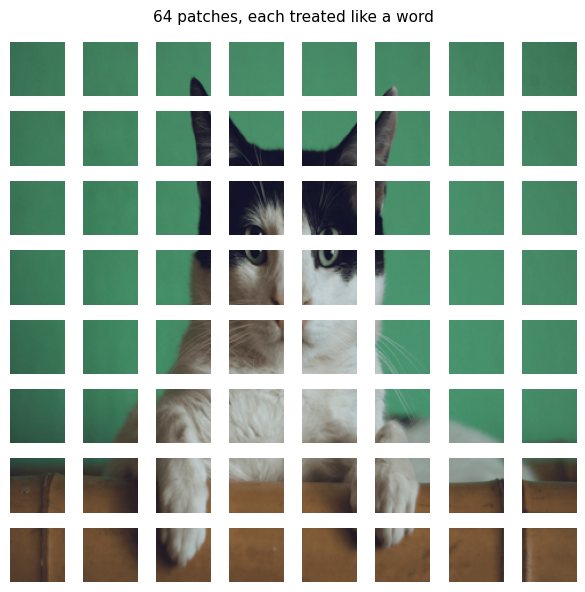

In [27]:
# RUN AS IS
# Download a sample image and slice it into a ViT style patch grid.
import urllib.request
from PIL import Image
import matplotlib.pyplot as plt

url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/cat.png"
urllib.request.urlretrieve(url, "sample_cat.png")
img = Image.open("sample_cat.png").convert("RGB").resize((384, 384))

def show_patches(image, patch_size=48):
    """Slice an image into square patches and display them as a spaced grid,
    the way a Vision Transformer sees its input."""
    w, h = image.size
    cols, rows = w // patch_size, h // patch_size
    fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
    for r in range(rows):
        for c in range(cols):
            patch = image.crop((c * patch_size, r * patch_size,
                                (c + 1) * patch_size, (r + 1) * patch_size))
            axes[r, c].imshow(patch)
            axes[r, c].axis("off")
    fig.suptitle(f"{rows * cols} patches, each treated like a word", fontsize=11)
    plt.tight_layout()
    plt.show()

show_patches(img)

Patch size = 48


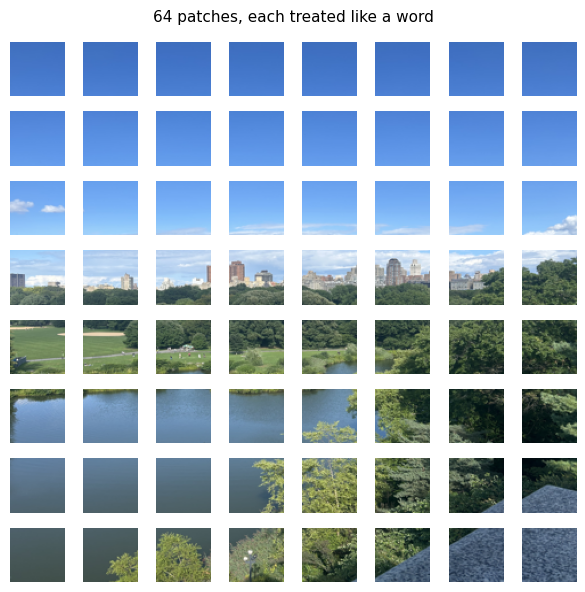

Patch size = 96


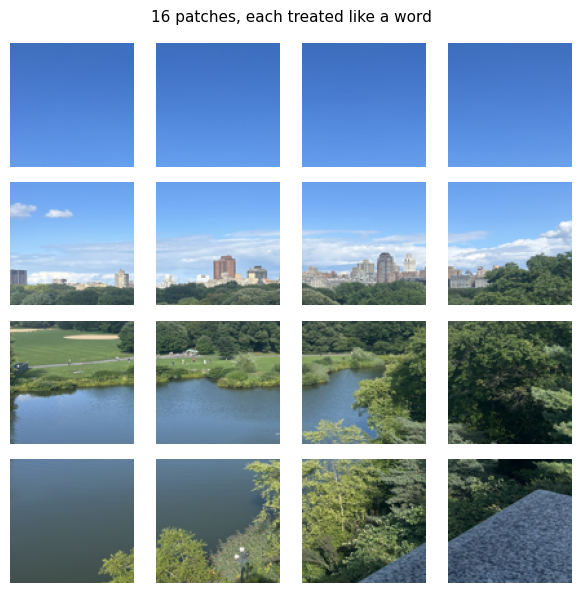

In [45]:
# YOUR CODE HERE (Patch grid, graded, 10 pts)

# TODO: load a DIFFERENT image (upload your own with the Colab folder icon,
#       or reuse a different URL) and display its patch grid at TWO patch
#       sizes: 48 and 96.
# Tip: resize to (384, 384) first so the grid divides evenly.
# Tip: img2 = Image.open("/content/yourfile.jpg").convert("RGB").resize((384, 384))
#      then call show_patches(img2, patch_size=48) and again with 96.

from PIL import Image

# NY Image
img2 = Image.open("/content/NY_0337.jpg").convert("RGB").resize((384, 384))

print("Patch size = 48")
show_patches(img2, patch_size=48)

print("Patch size = 96")
show_patches(img2, patch_size=96)

### Patches

**With 48 pixel patches versus 96 pixel patches, which grid would give the model a more detailed "sentence" to read, and what is the tradeoff? Answer in two or three sentences using the words of an image analogy.**

With a patch size of 48 pixels, the image is divided into 64 smaller patches, creating a longer visual sentence with more detailed visual words. This allows the model to capture finer details such as the skyline, trees, water, and people in the distance. With a patch size of 96 pixels, the image is divided into only 16 larger patches, creating a shorter visual sentence that is faster to process but contains less visual detail in each visual word.

## Section 3: Load the VLM and Have Your First Conversation

**RUN AS IS.** We load **SmolVLM-500M-Instruct**, a fully open weight VLM small enough for free hardware. Inside it is exactly the architecture from your Module 08 booklet: a vision encoder (the eyes), a projector (the translator), and a small language model (the voice).

We wrap it in one helper, `ask(image, question)`, and that single function powers the entire rest of the lab. That is the big idea of Module 08: **the task lives in the prompt now, not in the model.**

In [29]:
# RUN AS IS
from transformers import AutoProcessor, AutoModelForVision2Seq

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForVision2Seq.from_pretrained(MODEL_ID, torch_dtype=DTYPE).to(DEVICE)

def ask(image, question, max_new_tokens=150):
    """Ask the VLM one question about one image and return its answer."""
    messages = [{"role": "user",
                 "content": [{"type": "image"},
                             {"type": "text", "text": question}]}]
    prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor(text=prompt, images=[image], return_tensors="pt").to(DEVICE)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    answer = processor.batch_decode(out, skip_special_tokens=True)[0]
    # The decoded text contains the whole conversation; keep only the reply.
    return answer.split("Assistant:")[-1].strip()

print("VLM loaded. Say hello:")
print(ask(img, "Describe this image in one sentence."))

/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


VLM loaded. Say hello:
A cat is resting its head on a wooden surface and looking at the camera.


### YOUR TURN 1: Interview an Image (Graded, 10 pts)

Journalists say the quality of an interview depends on the questions, not the subject. Same here. Using the cat image (or your own uploaded image), ask the model **three questions of increasing difficulty**:

1. An easy factual question (what is in the image)
2. A detail question (color, position, count, background)
3. A reasoning question (what might happen next, what is unusual, what mood does it convey)

Print each question with its answer so both are visible in your output.

In [44]:
# YOUR CODE HERE (Your Turn 1)

# TODO: write your three questions and ask them.
# Tip: a loop keeps this readable:
# for q in [question_1, question_2, question_3]:
#     print("Q:", q)
#     print("A:", ask(img, q))
#     print()

question_1 = "What is shown in this image?"
question_2 = "Describe the buildings, trees, and water in this image and explain where they are located."
question_3 = "What mood does this image convey, and what visual elements create that mood?"

for q in [question_1, question_2, question_3]:
    print("Q:", q)
    print("A:", ask(img2, q))
    print()

Q: What is shown in this image?
A: A long shot shows a river in the foreground, with trees and a park in the background, and a city skyline in the distance with a few buildings and trees. The sky is clear and blue with a few, small, white clouds.

Q: Describe the buildings, trees, and water in this image and explain where they are located.
A: The image depicts a serene landscape with a focus on a river in the foreground and a cityscape in the background. The river occupies the lower half of the image, running horizontally across the frame. The water appears calm and reflects the blue sky above, indicating a clear day with good visibility.

In the background, the cityscape is dominated by a series of buildings. These structures are primarily made of brick and have a variety of architectural styles, suggesting a mix of old and new architecture. The buildings vary in height and design, with some appearing more modern and others more traditional. The skyline is partially obscured by a few 

### Your Turn 1

**Which of your three questions got the weakest answer, and why do you think that level of question is harder for the model? Two or three sentences.**

The second question (the detail question) received the weakest answer because the model included some inaccurate or unsupported details, such as specific building materials, architectural styles, and reflections in the water. This type of question is harder because it requires the model to identify precise visual information, which can lead it to hallucinate details that are not clearly visible in the image.

## Section 4: One Model, Many Jobs (Graded, 10 pts)

Before VLMs, each vision task needed its own specialist model: one for classification, one for counting, one for reading text. A VLM replaces the whole shelf, because **the prompt selects the job**. Watch the demo, then make the model switch jobs yourself.

**Prompting tip that professionals rely on:** constrain the output format. "Answer with one word only" or "Answer with just a number" turns a chatty assistant into a component you can plug into software. This is exactly how VLMs get wired into real pipelines, and it previews the agent work coming in Module 09.

In [31]:
# RUN AS IS
# Job 1, classification: the prompt turns the VLM into a classifier.
print("Classifier:", ask(img, "Is this a cat, a dog, or a bird? Answer with one word only."))

Classifier: Cat.


In [43]:
# YOUR CODE HERE (Job switching)

# TODO: make the SAME model do two more jobs on the same image:
#   Job 2, counter: ask how many of something there are, demanding just a number.
#   Job 3, reader/describer: ask it to list every object it can see, one per line.
# Tip: the only thing you are allowed to change is the question string.
#      That is the whole point of this section.

# Job 2: Counter
print("Counter:", ask(img, "How many cats are in this image? Answer with just a number."))

# Job 3: Reader/Describer
print("Objects:\n" + ask(img, "List every object you can see, one per line."))

Counter: 1.
Objects:
Green background, cat, brown surface, green background.


### One model, many jobs

**In Module 06 you used a dedicated detector (YOLO) for finding objects. Name one advantage the specialist detector still has over the VLM you just prompted, and one advantage the VLM has over the specialist. Two or three sentences.**

A specialist detector like YOLO is better at accurately locating and detecting objects with bounding boxes, making it more reliable for object detection tasks. A VLM is more flexible because the same model can perform many different tasks, such as classification, counting, description, and reasoning, simply by changing the prompt without training a separate model for each task.

## Section 5: Workforce Task A, Accessibility Alt Text (Graded, 10 pts)

Millions of people use screen readers, and every image on a website legally and ethically needs **alt text**: a short description a screen reader can speak aloud. Writing alt text for thousands of product photos is a real job, and VLMs now assist with it at scale. But quality depends entirely on the prompt.

Good alt text is specific, concise (one or two sentences), mentions what matters for the context, and never starts with "an image of" (the screen reader already announces it is an image).

Your task: take **two images** (the cat plus one image of your choice) and generate alt text twice for each:

1. First with a **weak prompt**: just "Describe this image."
2. Then with a **professional prompt you write** that encodes the rules above.

In [33]:
# YOUR CODE HERE (Workforce task A)

# TODO: write your professional alt text prompt. Encode the rules:
#       concise, specific, useful for a shopper or reader, never "an image of".
# Tip: you can put instructions AND constraints in one question, for example:
#      "Write alt text for this image for a screen reader user. One sentence,
#       specific, do not begin with the words an image of."

weak_prompt = "Describe this image."
pro_prompt = (
    "Write concise alt text for a screen reader user. "
    "Use one or two sentences, be specific and useful, "
    "and do not begin with the words 'an image of'."
)

# Cat image
print("=== Cat image ===")
print("Weak prompt:")
print(ask(img, weak_prompt))
print()

print("Professional prompt:")
print(ask(img, pro_prompt))
print()

# Central Park image
print("=== Central Park image ===")
print("Weak prompt:")
print(ask(img2, weak_prompt))
print()

print("Professional prompt:")
print(ask(img2, pro_prompt))

=== Cat image ===
Weak prompt:
The image depicts a domestic cat resting on a wooden surface, likely a table or shelf. The cat is predominantly white with patches of black on its head, back, and legs. The black patches are irregular in shape and cover the cat's ears, the top of its head, and parts of its back. The cat's eyes are green, and its fur appears soft and well-groomed.

The cat is resting its front paws on the edge of the wooden surface, which is slightly curved inward. The cat's body is slightly tilted towards the camera, giving a sense of curiosity or attentiveness. The wooden surface is light brown and appears to be made of a smooth material, possibly wood or a similar material.

The

Professional prompt:
A cat is resting its head on a wooden surface.

=== Central Park image ===
Weak prompt:
An outdoor, high-angle view shows a wide, calm river in the foreground, flanked by a green lawn and trees on the left and a cityscape on the right. The cityscape includes several high-ri

### Alt text

**Compare the weak and professional outputs. What specifically improved, and what would you still fix by hand before publishing? Two or three sentences.**

The professional prompt produced shorter and more focused alt text, making it more appropriate for screen readers by including only the most important information. Before publishing, I would still edit it by hand to add more meaningful details, such as identifying the location as Central Park and mentioning the skyline, since the generated alt text was accurate but somewhat too general.

## Section 6: Workforce Task B, Reading Documents and Charts (Graded, 10 pts)

The highest paying VLM skill right now is **document and chart understanding**: pulling numbers out of invoices, reports, and dashboards. Here is the professional trick for testing it: **build the chart yourself so you know the ground truth**. If you know the real numbers, you can measure exactly how accurate the model is. Never trust an extraction you cannot check.

**RUN AS IS** builds a sales chart with known values. Then you interrogate it.

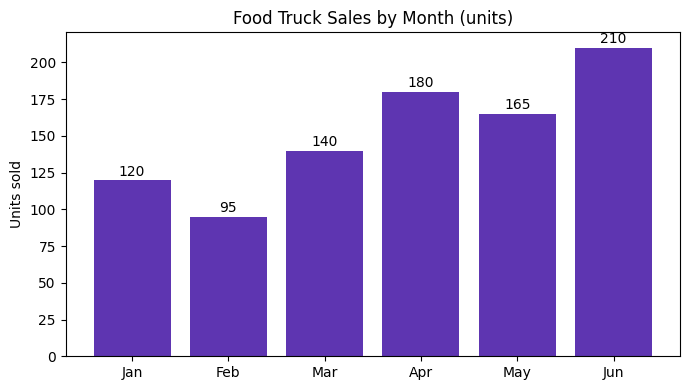

Chart built. Ground truth: {'Jan': 120, 'Feb': 95, 'Mar': 140, 'Apr': 180, 'May': 165, 'Jun': 210}


In [34]:
# RUN AS IS
# Build a bar chart with KNOWN values, save it, and load it as an image.
import matplotlib.pyplot as plt
from PIL import Image

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
sales = [120, 95, 140, 180, 165, 210]   # ground truth, we KNOW these numbers

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(months, sales, color="#5E35B1")
ax.set_title("Food Truck Sales by Month (units)")
ax.set_ylabel("Units sold")
for i, v in enumerate(sales):
    ax.text(i, v + 3, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("sales_chart.png", dpi=110)
plt.show()

chart = Image.open("sales_chart.png").convert("RGB")
print("Chart built. Ground truth:", dict(zip(months, sales)))

In [35]:
# YOUR CODE HERE (Workforce task B)

# TODO: ask the model AT LEAST three questions about the chart and print the
#       answers next to the true values so accuracy is visible. Ideas:
#   1. Which month had the highest sales?
#   2. How many units were sold in March? (Answer with just the number.)
#   3. Did sales go up or down between April and May?
# Tip: ask(chart, your_question)
# Tip: at least one question should require comparing two bars, which is
#      harder than reading one printed number.

# Question 1
print("Question 1: Which month had the highest sales?")
print("Model:", ask(chart, "Which month had the highest sales?"))
print("Ground truth: Jun")
print()

# Question 2
print("Question 2: How many units were sold in March?")
print("Model:", ask(chart, "How many units were sold in March? Answer with just the number."))
print("Ground truth: 140")
print()

# Question 3
print("Question 3: Did sales go up or down between April and May?")
print("Model:", ask(chart, "Did sales go up or down between April and May?"))
print("Ground truth: Down")

Question 1: Which month had the highest sales?
Model: Jun
Ground truth: Jun

Question 2: How many units were sold in March?
Model: 140.
Ground truth: 140

Question 3: Did sales go up or down between April and May?
Model: Sales went up.
Ground truth: Down


### YOUR ANSWER (Chart reading)

**Score the model: how many of your questions did it answer correctly against the ground truth? Would you trust it unsupervised with a company's financial dashboard? Two or three sentences.**

The model answered 2 out of 3 questions correctly. I would not trust it to analyze a company's financial dashboard without human supervision because it made an incorrect comparison between April and May, showing that it can make mistakes even when the data is clearly displayed.

## Section 7: YOUR TURN 2, The Hallucination Hunt (Graded, 10 pts)

Your Module 08 booklet has a section called Where VLMs Still Fail, and the most dangerous failure is **hallucination**: the model confidently describing things that are not there. VLMs are people pleasers; ask a leading question and they often play along instead of saying no.

Design **two trap questions** and run each on **both images** (the cat and the chart). A trap question presupposes something false, for example:

* "What color is the dog's collar?" (asked about an image with no dog)
* "What does the sign in the background say?" (no sign exists)
* "Why did sales drop in June?" (they rose)

A model passes the trap by correcting you. It fails by inventing an answer.

In [36]:
# YOUR CODE HERE (Your Turn 2)

# TODO: write two trap questions of your own (do not copy the examples) and
#       run each on BOTH images, printing all four exchanges clearly.
# Tip: the best traps sound casual and confident, exactly like a distracted
#      coworker would ask.

trap_1 = "What color are the cat's blue eyes?"
trap_2 = "Which month had the lowest sales after July?"

# Cat image
print("=== Cat image ===")
print("Trap 1:")
print("Q:", trap_1)
print("A:", ask(img, trap_1))
print()

print("Trap 2:")
print("Q:", trap_2)
print("A:", ask(img, trap_2))
print()

# Sales chart
print("=== Sales chart ===")
print("Trap 1:")
print("Q:", trap_1)
print("A:", ask(chart, trap_1))
print()

print("Trap 2:")
print("Q:", trap_2)
print("A:", ask(chart, trap_2))

=== Cat image ===
Trap 1:
Q: What color are the cat's blue eyes?
A: The cat has black eyes.

Trap 2:
Q: Which month had the lowest sales after July?
A: The provided facts do not mention any sales or months, so it is not possible to answer this question.

=== Sales chart ===
Trap 1:
Q: What color are the cat's blue eyes?
A: There is no cat present in the image, so it is not possible to determine the color of its eyes.

Trap 2:
Q: Which month had the lowest sales after July?
A: February.


### Hallucination report

**For each trap, did the model correct you or play along? Why is this failure mode more dangerous in a workplace than simply getting a count wrong? Three or four sentences.**

For the cat image, the model played along with the first trap by inventing that the cat had black eyes, but it correctly rejected the second trap because the question was unrelated to the image. For the chart, it correctly said there was no cat in the image, but it failed the second trap by inventing an answer even though there were no months after July. This type of failure is more dangerous in the workplace because hallucinated information can appear believable and lead people to make decisions based on false data, whereas an incorrect count is often easier to detect and verify.

## Section 8: Preview, The Agent's Eyes (Bridge to Module 09)

**RUN AS IS.** In Module 09 you will build AI agents that perceive, reason, and act. Their perception step is exactly what you have been doing all lab: a VLM answering questions about what it sees. Here is a thirty second preview: we ask the model not just to describe, but to **recommend an action**, which is the seed of the agent loop.

In [37]:
# RUN AS IS
# The same ask() function, but the prompt now requests a decision.
agent_question = (
    "You are a monitoring assistant for a pet daycare. Based on this camera "
    "image, report the situation in one sentence and recommend one action. "
    "Format: SITUATION: ... ACTION: ..."
)
print(ask(img, agent_question))

Monitor the cat's eye color.


Notice what changed: nothing in the model, everything in the prompt. Perception plus a decision format is the doorway to agents. Hold that thought for two weeks.

## Section 9: Try It Yourself, The Deployment Audit (Graded, 20 pts)

This section is fully yours. No scaffolding, no starter code. Your only tools: `ask()`, `show_patches()`, matplotlib, and your judgment.

**The scenario:** You are a junior CV technician. Your manager is considering using a small VLM for one workplace task and asks you to **audit it before anyone trusts it**. You choose the scenario:

* Retail: describing product photos for a store website
* Safety: reporting what is visible on a workplace camera image
* Accessibility: alt text for a community organization's photo library
* Education: describing diagrams or charts for students
* Your own idea (name it clearly)

**Your deliverable, in cells you write yourself:**

1. **The scenario and test set (5 pts):** name your scenario and assemble two or three test images that fit it (upload your own, reuse the chart trick from Section 6 to build controlled test images, or reuse the provided images if they genuinely fit).
2. **The reliability test (5 pts):** design ONE prompt for the task, then test it for consistency by asking the same thing **three different ways** (rephrase it twice) on the same image. A dependable tool gives consistent answers; a fragile one changes its story.
3. **The audit memo (10 pts):** in the answer cell below, write a five to eight sentence memo to your manager: what you tested, what the model got right, what it got wrong or inconsistent, one hallucination risk specific to your scenario, and your verdict: deploy with human review, deploy unsupervised, or do not deploy. Take a position and defend it with your evidence.

**GPU saver:** ten to fifteen questions total is plenty. A sharp audit beats a big one.

In [38]:
# YOUR CODE HERE (Try It Yourself)
print("=== Deployment Audit ===")
print("Scenario: Accessibility - Generating alt text for a community organization's photo library.")
print()

print("Test Images:")
print("1. Cat image")
print("2. Central Park image")
print("3. Sales chart")
print()

# Three versions of the same task
prompt_1 = "Write concise alt text for this image."
prompt_2 = "Write one sentence of alt text for a screen reader user."
prompt_3 = "Describe this image as accessible alt text in one concise sentence."

print("=== Reliability Test (Central Park image) ===\n")

for i, prompt in enumerate([prompt_1, prompt_2, prompt_3], start=1):
    print(f"Prompt {i}:")
    print("Q:", prompt)
    print("A:", ask(img2, prompt))
    print()

=== Deployment Audit ===
Scenario: Accessibility - Generating alt text for a community organization's photo library.

Test Images:
1. Cat image
2. Central Park image
3. Sales chart

=== Reliability Test (Central Park image) ===

Prompt 1:
Q: Write concise alt text for this image.
A: A low angle view of a river in front of a cityscape is captured with a bright blue sky and a few scattered clouds behind. The river is a muted green, reflecting the trees and buildings on the far shore. The trees are lush and green, and there is a large, open green space in the foreground, with a pond and some grassy areas. In the background, a cityscape is visible, with several high-rise buildings and a few smaller structures. The sky is a clear blue, with a few scattered clouds. A large gray stone wall is visible in the foreground on the right side of the frame.

Prompt 2:
Q: Write one sentence of alt text for a screen reader user.
A: In an eye-level outdoor shot, the low angle reveals a wide, dark river 

### Audit memo

**Your five to eight sentence memo to your manager. What you tested, what worked, what failed or wavered, one scenario specific hallucination risk, and your verdict with reasons.**

I tested a small Vision Language Model for generating accessibility alt text for a community organization's photo library. My test set included a cat image, a Central Park photo, and a sales chart, and I evaluated consistency by asking for alt text in three different ways for the same image. The model consistently identified the main elements of the scene, but the level of detail and wording varied, and it sometimes included unnecessary camera-related descriptions instead of focusing on accessibility. Earlier in the lab, the model also hallucinated information when given misleading questions, showing that it can confidently produce incorrect descriptions. In this scenario, hallucinated objects or details could mislead screen reader users and reduce the accessibility of the content. My verdict is to deploy the model only with human review because it produces useful first drafts but is not reliable enough to publish alt text without verification.

## Section 10: Reflection Questions (Graded, 20 pts, 2 each)

Answer each question in complete sentences directly in its YOUR ANSWER cell. Short bullet answers will not earn full credit. I want your reasoning in your own words.

**Q1. Patches as words.** Explain to a friend with no AI background how a Vision Transformer reads an image, using the patch grid you made in Section 2. Use your own analogy, not one from this notebook.

**Answer:** I think of a Vision Transformer like someone looking at a city through many small windows instead of seeing the entire view at once. Each window captures only a small part of the scene, such as a tree, a building, or a section of the sky. The model analyzes those small sections and then connects the information to understand the full image. Smaller patches create more windows and preserve finer details, while larger patches create fewer windows and give the model a more general view of the scene.

**Q2. The three part architecture.** A VLM has eyes (vision encoder), a translator (projector), and a voice (language model). When your model hallucinated in Section 7, which part do you suspect was most responsible, and why?

**Answer:** I think the language model was the most responsible for the hallucinations. In Section 7, the vision encoder seemed to recognize the main content of the images, but the language model generated confident answers based on false assumptions instead of correcting them. For example, when I intentionally asked which month had the lowest sales after July, even though the chart ended in June, it answered "February" instead of pointing out that the question was invalid. This suggests that the model's biggest weakness was generating a plausible response rather than rejecting a false premise.

**Q3. The prompt is the task.** In Section 4 one model did several jobs. What does this mean for how CV teams will be organized in the workplace: fewer specialist models to maintain, or new problems to manage? Name one of each.

**Answer:** Section 4 showed that a single Vision Language Model can perform many different computer vision tasks simply by changing the prompt. This means CV teams may need to maintain fewer specialized models, making deployment and updates simpler. However, it also creates new challenges because prompt design and output validation become much more important. As I observed in this lab, the same model could complete different tasks but also hallucinate or produce inconsistent answers, so teams must carefully test prompts and review the model's responses before relying on them in real applications.

**Q4. Constrained outputs.** Why does "answer with just a number" matter so much when a VLM is wired into software instead of chatting with a person? Give a concrete example of what breaks without it.

**Answer:** When a VLM is connected to software, its output often becomes the input for another program, so the format must be predictable. Asking for "just a number" ensures that the next step can read the result without extra processing or errors. For example, if an inventory system expects the number "5" but the model returns "There are five items visible in the image," the software may fail to interpret the answer correctly or generate an error. Constrained outputs make automation more reliable and reduce the risk of failures caused by unexpected responses.

**Q5. Small versus frontier.** You used a 500 million parameter open model today; Module 08 covered frontier models thousands of times larger. Name two workplace situations where the small local model is the RIGHT choice even though it is weaker.

**Answer:** A small local model is the right choice when privacy is a priority, such as analyzing medical images or confidential company documents that should not be sent to a cloud service. It is also a good choice for offline or low-cost environments, such as running image analysis on factory equipment or edge devices with limited internet access. Although a larger frontier model may be more accurate, a small local model offers better privacy, lower operating costs, and faster local inference, which can be more important in these situations.

**Q6. Alt text ethics.** Who is harmed when auto generated alt text is wrong, and why is "a human reviews every caption" easier to promise than to deliver at the scale of a real website?

**Answer:** People who rely on screen readers are harmed when auto-generated alt text is incorrect because they may receive misleading or incomplete information about an image. This can reduce accessibility and prevent them from understanding the same content available to other users. Although requiring a human to review every caption sounds like a good solution, it is difficult to achieve on large websites that may contain thousands or even millions of images. Reviewing every caption takes significant time and resources, making it challenging to maintain both accuracy and efficiency at scale.

**Q7. Ground truth.** In Section 6 you built the chart yourself so you knew the true numbers. Why is this a professional habit, and what goes wrong when teams evaluate AI tools on data where nobody knows the right answers?

**Answer:** Using ground truth is a professional habit because it provides an objective way to measure whether an AI system is actually correct. In Section 6, I built the chart myself, so I knew the correct answers and could immediately identify when the model made mistakes. If teams evaluate AI on data where nobody knows the right answers, they may mistake confident but incorrect responses for accurate ones. This can lead to deploying unreliable systems because there is no reliable way to measure their performance or detect hallucinations.

**Q8. Hallucination versus error.** Using your Section 7 results, explain the difference between a model being wrong and a model hallucinating. Why is the second one harder to catch in a busy workplace?

**Answer:** A model is simply wrong when it gives an incorrect answer about information that is actually present, such as saying that sales increased between April and May when they actually decreased. A hallucination is different because the model invents information that is not supported by the image or the data. In Section 7, for example, it answered "February" to a question about the month after July, even though the chart ended in June, and it invented the cat's eye color instead of correcting the false assumption. Hallucinations are harder to catch in a busy workplace because the answers often sound confident and believable, so people may accept them without realizing they are unsupported by the data.

**Q9. The audit mindset.** Your Try It Yourself verdict required taking a position. What evidence would have changed your verdict to the opposite one? Being able to answer this is what separates an audit from an opinion.

**Answer:** I would have changed my verdict if the model had consistently produced accurate results across all of the tasks in this lab, including correctly answering questions about the chart, avoiding hallucinations when given misleading prompts, and generating reliable alt text without inventing details. If repeated testing showed that these errors rarely occurred, I would be more confident recommending deployment without routine human review. An audit should be based on measurable evidence rather than personal opinion, so my conclusion would change if the evidence changed.

**Q10. Changed mind.** Before this lab, what did you believe about how AI understands images that turned out to be wrong or incomplete? Be specific about which section changed your mind.


**Answer:** Before this lab, I assumed that if an AI model could correctly identify the main content of an image, it also understood the image well enough to answer questions reliably. Section 7 showed me that this was incomplete. The model often recognized the image correctly but still accepted false assumptions and invented unsupported answers, such as giving a month after July when the chart ended in June. This changed my understanding because I realized that recognizing visual content is not the same as reasoning accurately about it.

## Section 11: Optional Bonus Challenges (up to +20)

Each completed challenge earns 5 bonus points. Pick any, all, or none. All four are light on compute.

**Bonus A, The tiny sibling (+5):** Load `HuggingFaceTB/SmolVLM-256M-Instruct` (half the size, a fast extra download) and rerun your three Your Turn 1 questions on it. In one or two sentences: what did shrinking the model cost?

**Bonus B, The receipt reader (+5):** Using PIL, draw your own fake receipt image (store name, three items with prices, a total) with `ImageDraw.text`, then ask the model to extract the total and one item price. You know the ground truth because you drew it.

**Bonus C, The patch size probe (+5):** Take one image with small important detail (text or a small object). Show its patch grid at 96 pixels, then ask the model a question about that small detail. Connect what you see in the grid to how the model answered, in one or two sentences.

**Bonus D, Your own photo set (+5):** Complete your Try It Yourself audit entirely with photos you took yourself. If you already did, say so here and point to the cells.

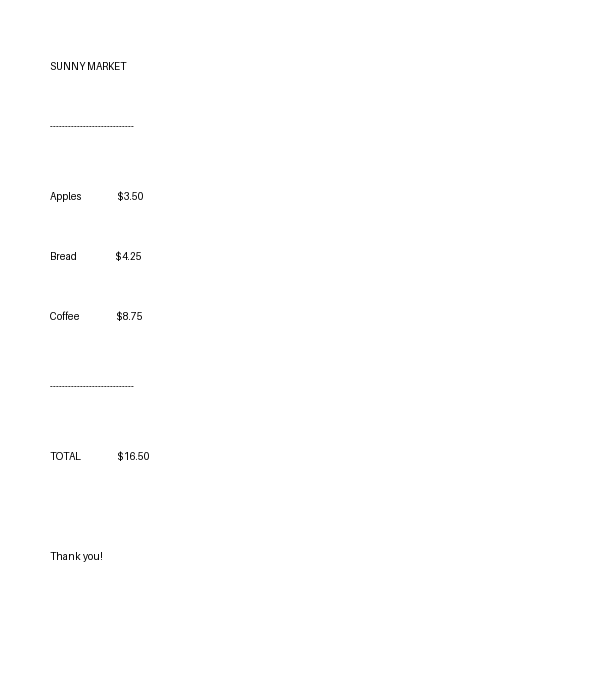

In [39]:
# YOUR CODE HERE (Optional bonus work)
# BONUS B — THE RECEIPT READER

from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# Create a blank receipt image
receipt = Image.new("RGB", (600, 700), "white")
draw = ImageDraw.Draw(receipt)

try:
    font = ImageFont.truetype("DejaVuSans.ttf", 30)
    small_font = ImageFont.truetype("DejaVuSans.ttf", 26)
except:
    font = ImageFont.load_default()
    small_font = ImageFont.load_default()

receipt_text = [
    ("SUNNY MARKET", 60, font),
    ("----------------------------", 120, small_font),
    ("Apples                  $3.50", 190, small_font),
    ("Bread                   $4.25", 250, small_font),
    ("Coffee                  $8.75", 310, small_font),
    ("----------------------------", 380, small_font),
    ("TOTAL                  $16.50", 450, font),
    ("Thank you!", 550, small_font)
]

for text, y, text_font in receipt_text:
    draw.text((50, y), text, fill="black", font=text_font)

display(receipt)

In [40]:
print("TOTAL:")
print(ask(receipt, "What is the total on this receipt? Answer with only the price."))

print("\nBREAD PRICE:")
print(ask(receipt, "What is the price of the bread? Answer with only the price."))

TOTAL:
$16.50.

BREAD PRICE:
$4.25.


### Bonus B Reflection

The model correctly extracted both values from the receipt, showing that it can perform simple OCR tasks on clear, well-formatted documents. However, the results should still be verified against the original receipt because real receipts often contain poor image quality, unusual layouts, or handwritten text that can increase the chance of errors.

Patch size = 96


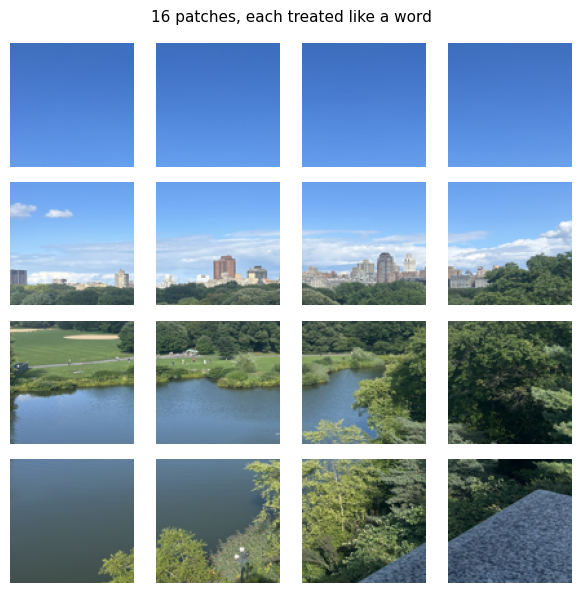

In [41]:
# YOUR CODE HERE (Optional bonus work)
# BONUS C — PATCH SIZE PROBE

from PIL import Image

ny_image = Image.open("NY_0337.jpg").convert("RGB")
ny_384 = ny_image.resize((384, 384))

print("Patch size = 96")
show_patches(ny_384, patch_size=96)

In [42]:
print(ask(ny_image, "Are there people walking on the path?"))

Yes, there are people on the path.


### Bonus C Reflection

With a 96-pixel patch size, each patch covers a larger portion of the image, so small details such as people on the walking path are represented with less precision. Even so, the model correctly identified that there were people on the path, showing that it can still recognize some small features despite the lower visual resolution.

### Bonus D Reflection

Yes. I completed the Try It Yourself audit using a photo that I took myself. The file is named NY_0337.jpg, and it is referred to as the Central Park image in the activity. See the cells where the Central Park image is uploaded and analyzed.

## Section 12: Submission Checklist

1. Choose Runtime, then Run all, one final time. Confirm there are no errors and every question and answer pair is visible.
2. Check that every **YOUR ANSWER** cell has your words in it (search the notebook for the word "replace" to find any you missed).
3. File, Download, Download .ipynb, **with all outputs visible**. Do not clear outputs.
4. Name it **L08_LastName_FirstName_ITAI1378.ipynb** and submit the notebook to Canvas. The notebook is the only deliverable.

Today you interviewed images, made one model wear five hats, caught it lying, and wrote a professional audit, all on a model small enough to run on a laptop. In Module 09 the VLM you just tamed becomes the **eyes of an agent** that perceives, reasons, and acts. You already wrote its first perception prompt in Section 8.

*Email or message me if you have any questions.*